# Notebook 3. Kernel statistics as the only covariates

**Question.** Can the kernel statistics `A_t`, `S_t` and `R_t`, read at a step before any run groks, tell us when a run will grok? Do they act alone or together, and what shape does the relation take?

Notebooks 1 and 2 also gave the models the settings (`alpha`, width and weight decay). The 5 seeds of one cell behave almost the same, so a model can learn each cell's typical grokking step and ignore the kernel. Here the models see only the kernel statistics, read at the prediction time $t^* = 2{,}430$. Notebook 4 asks the same questions for runs that grok, and measures how much of the data is noise.

**The model with interactions.** Most of this notebook builds on one regression. With $z_A$, $z_S$, $z_R$ the standardised statistics (using log `R_t`, as Part 1 explains),
$$\log T = \beta_0 + \beta_A z_A + \beta_S z_S + \beta_R z_R + \gamma_{AS}\, z_A z_S + \gamma_{AR}\, z_A z_R + \gamma_{SR}\, z_S z_R + \sigma\varepsilon, \qquad \varepsilon \sim N(0, 1).$$
Each $\gamma$ term is an interaction term, the product of two standardised statistics. A non-zero $\gamma_{SR}$ means the slope of $\log T$ in $z_S$ changes by $\gamma_{SR}$ for each standard deviation of $z_R$, and the reverse. Runs that never grok enter as "$T$ is above 200,000".

**Short answer.**
- **Rotation and alignment matter on every scale we tried.** More rotation and more alignment at $t^*$ go with earlier grokking. `R_t` works best on a log scale.
- **The statistics interact.** The interaction terms improve the fit on every scale. The clearest pair is `S_t` × `R_t`: growth of the kernel speeds grokking only when the kernel has also rotated. Which pairs look important depends on the scale used for `R_t`, so single pairs need care.
- **The relation is non-linear.** `S_t` has a best middle range, `R_t` acts on a log scale, and `A_t` matters mostly above 0.40. XGBoost ranks runs from a held-out `alpha` at 0.737, against 0.655 for the linear model with interactions.
- **The history adds a little.** The statistics are strongly autocorrelated over training. A GRU that reads their history scores 0.765.
- **The settings predict better.** XGBoost on width and weight decay alone scores 0.779, above every kernel model.

## Words used in this notebook

| Term | Meaning |
| --- | --- |
| grokking step `T` | The first saved step at which test accuracy reaches 0.95 (golden report §3.5). |
| censored run | A run that never reaches 0.95 within 200,000 steps. We only know that `T` is above 200,000. These runs are kept. |
| cell | One mix of `alpha`, width and weight decay. Each cell has 5 seeds. |
| `S_t` | Kernel scale. The size of the kernel at step t divided by its size at the start (golden report Eq. 6). 1 means no change and below 1 means it shrank. |
| `R_t` | Kernel rotation. One minus the cosine between the kernel at step t and at the start. 0 means the same shape. |
| `A_t` | Kernel alignment. How well the kernel lines up with the labels, between 0 and 1. As in the golden report, it uses the labels of the 53 test pairs, the same pairs that define `T`. |
| prediction time $t^*$ | Step 2,430. Every run is still ungrokked here, so the statistics are read at this step. Survival analysis calls it the landmark time. |
| cross-sectional covariates | The three statistics at $t^*$. Parts 1 to 4 use these. |
| longitudinal covariates | The statistics at all 25 saved steps up to $t^*$, a short time series for each run. Part 5 uses these. |
| standardised | Minus the mean and divided by the standard deviation of the training runs. We write $z_A$, $z_S$, $z_R$. |
| interaction term | The product of two standardised statistics, such as $z_A z_S$. It lets the effect of one statistic depend on the other. |
| AFT model | Accelerated failure time model. A regression of $\log T$ that counts a censored run as "$T$ is above 200,000". |
| concordance | Pick two runs. It is the share of pairs that the model puts in the right order. 0.5 is a coin toss and 1 is perfect. |
| validation set | Training runs held back to choose a model's settings. They are never the test runs. |

## How the models are tested

**The split inside each run.** Each network trains on 90% of the 529 pairs and is tested on the other 53. Test accuracy on those 53 pairs defines `T`. Every run uses the same split (data seed 42), while the golden report gives each seed its own (§3.1).

**No random train/test split of runs.** The 5 seeds of a cell are near copies. A random split would put copies on both sides, and the test score would reward remembering cells. So we always hold out whole groups of runs.

**Outer loop: hold out one `alpha`.**

| Fold | Fit on | Predict |
| --- | --- | --- |
| 1 | `alpha` 1 and 2 | `alpha` 0.5 |
| 2 | `alpha` 0.5 and 2 | `alpha` 1 |
| 3 | `alpha` 0.5 and 1 | `alpha` 2 |

The model never sees a run with the held-out `alpha`. We score each fold with the concordance and report the mean of the three. Part 2 is the exception. It fits all runs to describe links and makes no claim about prediction.

**Inner loop: choosing model settings.** Settings are chosen from the training runs of each fold only.
- XGBoost holds out 20% of the training cells as a validation set. It tries 24 settings (tree depth 1 to 4, learning rate 0.03 or 0.1, minimum child weight 1, 5 or 10). Each one stops when the validation loss has not improved for 50 rounds. The setting with the best validation concordance is refitted on all training runs.
- Kernel ridge chooses its penalty and width by 5-fold cross-validation that holds out whole cells.
- The linear AFT has no settings to choose. A small fixed penalty of 0.01 keeps it stable.
- The GRU network in Part 5 has a fixed design. Its number of training epochs is chosen by early stopping on a validation set of cells.

**Repeats.** The seed changes the validation draw, the XGBoost subsampling and the starting weights of the GRU. We repeat these models over seeds and show the spread. These notebooks are exploratory and compare many models, so treat a gap below about 0.03 in concordance as noise.

## Setup

In [1]:
import copy
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb     # import XGBoost before PyTorch (Part 5), or their two copies of OpenMP clash
from scipy.stats import chi2
from lifelines import LogNormalAFTFitter
from lifelines.utils import concordance_index
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, GroupKFold

plt.style.use('fitting.mplstyle')
GREY, INK, PALE = '#8a8984', '#0b0b0b', '#c8c7c2'
KERNEL_COLOURS = {'A_t': '#7b5cd6', 'S_t': '#1a9e8f', 'R_t': '#c99a06', 'log R_t': '#c99a06'}
kernel = ['A_t', 'S_t', 'R_t']                                # the statistics as stored
covs = ['A_t', 'S_t', 'log R_t']                              # what the models use (Part 1 explains log R_t)
pairs = [('A_t', 'S_t'), ('A_t', 'R_t'), ('S_t', 'R_t')]
T_STAR = 2_430                                                # prediction time t*

## Load the data

We use every cell with weight decay up to 1e-3: 630 runs. `T` is the grokking step, or 200,000 for a censored run.

In [2]:
runs = pd.read_parquet('data/runs.parquet', columns=['run_id', 'alpha', 'width', 'eta_kappa', 'seed', 'last_step'])
acc = pd.read_parquet('data/checkpoints.parquet', columns=['run_id', 'step', 'test_acc'])
kern = pd.read_parquet('data/report_kernel.parquet')

events = runs.set_index('run_id')
events['t_gen95'] = acc[acc['test_acc'] >= 0.95].groupby('run_id')['step'].min()
events = events.reset_index()
events['grokked'] = events['t_gen95'].notna().astype(int)     # 1 = grokked, 0 = censored
events['T'] = events['t_gen95'].fillna(events['last_step'])    # the grokking step, or 200,000 if censored
events['cell'] = (events['alpha'].astype(str) + '_' + events['width'].astype(str) + '_'
                  + events['eta_kappa'].map('{:g}'.format))

data = events.merge(kern[kern['step'] == T_STAR].drop(columns='step'), on='run_id')
data = data[data['eta_kappa'] <= 1e-3].reset_index(drop=True)
data['log R_t'] = np.log(data['R_t'])
alphas = sorted(data['alpha'].unique())
assert data['T'].min() > T_STAR     # no run has grokked when we read the kernel
data.groupby('alpha')['grokked'].agg(runs='size', grokked='sum')

,runs,grokked
alpha,,
0.5,210,178
1.0,210,130
2.0,210,47


## Part 1. Look at the data

**Question.** How does each statistic at $t^*$ relate to the grokking step?

Each dot is one run. Filled dots grokked, and their height is `T`. Hollow dots never grokked and are drawn at 200,000. `R_t` is drawn on a log axis because it spans three orders of magnitude.

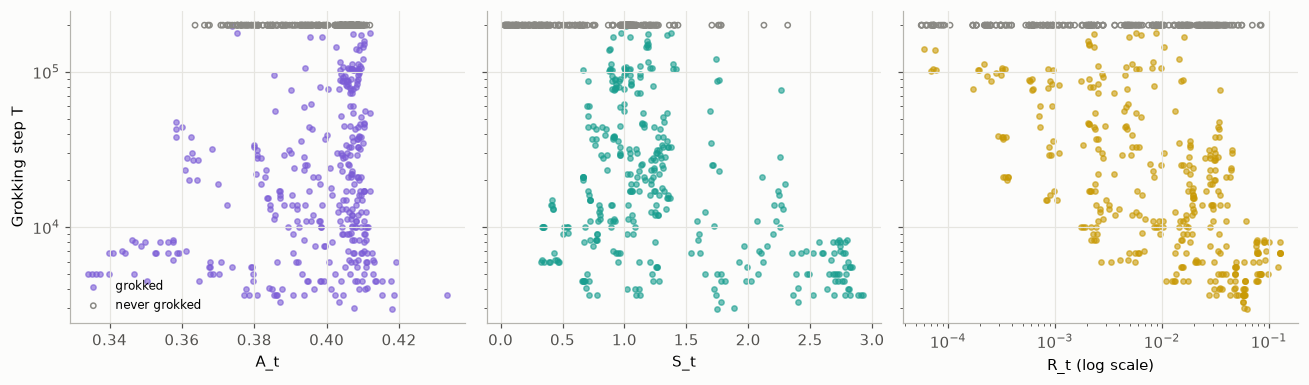

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
grokked, censored = data[data['grokked'] == 1], data[data['grokked'] == 0]
for ax, stat in zip(axes, kernel):
    ax.scatter(grokked[stat], grokked['T'], s=12, color=KERNEL_COLOURS[stat], alpha=0.6, label='grokked')
    ax.scatter(censored[stat], censored['T'], s=12, facecolors='none', edgecolors=GREY, label='never grokked')
    ax.set_xlabel(stat)
    ax.set_yscale('log')
axes[2].set_xscale('log')
axes[2].set_xlabel('R_t (log scale)')
axes[0].set_ylabel('Grokking step T')
axes[0].legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

Next, how the statistics differ between the values of `alpha`, and how strongly they move together. If one `alpha` sits apart from the others, a model trained on the other two has to reach outside what it has seen.

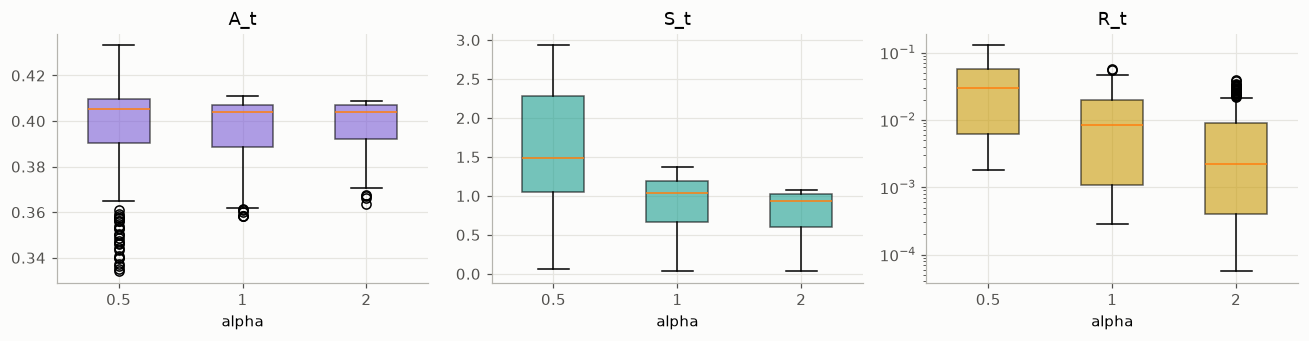

Correlation between the covariates:


,A_t,S_t,log R_t
A_t,1.00,-0.38,-0.59
S_t,-0.38,1.00,0.35
log R_t,-0.59,0.35,1.00


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, stat in zip(axes, kernel):
    box = ax.boxplot([g[stat] for _, g in data.groupby('alpha')], tick_labels=['0.5', '1', '2'], patch_artist=True, widths=0.5)
    for patch in box['boxes']:
        patch.set_facecolor(KERNEL_COLOURS[stat])
        patch.set_alpha(0.6)
    ax.set_xlabel('alpha')
    ax.set_title(stat)
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()
print('Correlation between the covariates:')
data[covs].corr().round(2)

**What this shows**
- Rotation has the clearest link. On a log scale, runs whose kernel has rotated more by $t^*$ grok sooner. Because `R_t` spans three orders of magnitude, every model below uses log `R_t`.
- `S_t` has no simple trend. Kernels that shrank a lot (`S_t` below about 0.3) mostly never grok.
- Most runs have `A_t` between 0.38 and 0.41. A small group with `A_t` below 0.37 groks early, so `A_t` does not push in one direction only. Part 5 shows where this group comes from.
- `S_t` and `R_t` shift with `alpha`. At `alpha` 0.5 the kernel grows and rotates most, and at `alpha` 2 it hardly rotates (median `R_t` 0.002). A model fitted on two values of `alpha` must reach outside its data for the third.
- `A_t` and log `R_t` move together (correlation −0.59), so their separate effects are hard to pull apart.

## Part 2. Which statistics are linked to grokking, and do they interact?

**Question.** Holding the others fixed, does each statistic go with earlier or later grokking? And does the effect of one depend on another?

We fit the AFT model with interactions from the top of the notebook on all 630 runs. A coefficient $a$ multiplies the median grokking step by $e^a$ for one standard deviation more of that term. A negative $a$ means sooner. This part describes links in the data. Part 3 tests prediction.

We fit three versions, to see which findings depend on how the statistics are measured:
1. **raw `R_t`**: `R_t` on its own scale.
2. **log `R_t`**: our main version. Part 1 shows why the log suits `R_t`.
3. **log `R_t` + squares**: version 2 plus $z_A^2$, $z_S^2$ and $z_R^2$. A square lets a statistic bend the curve on its own, so an interaction that only stood in for a bend should shrink here.

In versions 2 and 3, every term labelled `R_t` uses log `R_t`. The likelihood ratio (LR) test below asks whether the three interaction terms improve the fit in each version. It treats all 630 runs as independent, but the 5 seeds of a cell are near copies, so its p-values are too small. The cell bootstrap after it gives the fairer error bars.

In [5]:
specs = ['raw R_t', 'log R_t', 'log R_t + squares']


def design(df, spec, interactions=True, ref=None):
    # Standardise the statistics with the mean and spread of `ref` (default: all runs), then add product and square terms.
    ref = data if ref is None else ref
    cols = ['A_t', 'S_t', 'R_t' if spec == 'raw R_t' else 'log R_t']
    z = (df[cols] - ref[cols].mean()) / ref[cols].std()
    z.columns = kernel     # in the log versions, the R_t column holds log R_t
    X = z.copy()
    if interactions:
        for a, b in pairs:
            X[f'{a} × {b}'] = z[a] * z[b]
    if spec == 'log R_t + squares':
        for c in kernel:
            X[f'{c}²'] = z[c] ** 2
    return X


def fit_aft(df, X, penalizer=1e-4):
    return LogNormalAFTFitter(penalizer=penalizer).fit(X.assign(T=df['T'].to_numpy(), grokked=df['grokked'].to_numpy()), 'T', 'grokked')


fits, lr_tests = {}, {}
for spec in specs:
    fits[spec] = fit_aft(data, design(data, spec))
    without = fit_aft(data, design(data, spec, interactions=False))
    lr = 2 * (fits[spec].log_likelihood_ - without.log_likelihood_)
    lr_tests[spec] = {'LR statistic': round(lr, 1), 'p': f'{chi2.sf(lr, 3):.1e}'}
pd.DataFrame(lr_tests).T

,LR statistic,p
raw R_t,37.8,3.2e-08
log R_t,76.9,1.4e-16
log R_t + squares,133.3,1.0e-28


### How sure are we, and does it depend on the version?

We redo each fit 200 times. Each time we draw whole cells at random with replacement, so the 5 seeds of a cell stay together. The middle 95% of the refitted coefficients gives an error bar that respects the near copies. A finding we can trust keeps its sign, and its bar stays clear of 0, in all three versions.

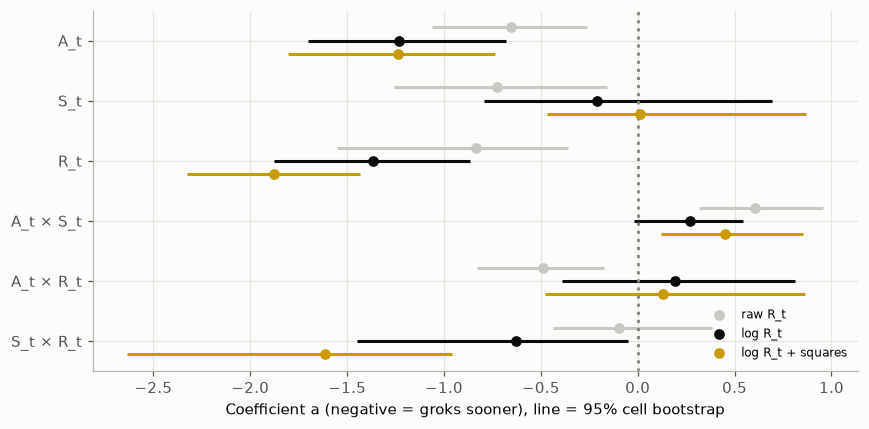

,coefficient,lower 95%,upper 95%
A_t,-1.23,-1.70,-0.68
S_t,-0.21,-0.79,0.69
R_t,-1.37,-1.88,-0.86
A_t × S_t,0.27,-0.02,0.54
A_t × R_t,0.19,-0.39,0.81
S_t × R_t,-0.63,-1.45,-0.05


In [6]:
rng = np.random.default_rng(0)
cells = data['cell'].unique()
boot = []
for _ in range(200):
    pick = rng.choice(cells, size=len(cells), replace=True)
    sample = data.iloc[np.concatenate([np.flatnonzero(data['cell'] == c) for c in pick])].reset_index(drop=True)
    for spec in specs:
        boot.append({'spec': spec, **fit_aft(sample, design(sample, spec)).params_.loc['mu_'].drop('Intercept')})
boot = pd.DataFrame(boot)

terms = kernel + [f'{a} × {b}' for a, b in pairs]
fig, ax = plt.subplots(figsize=(8, 4))
for j, (spec, colour) in enumerate(zip(specs, [PALE, INK, KERNEL_COLOURS['R_t']])):
    estimate = fits[spec].params_.loc['mu_'][terms]
    spread = boot.loc[boot['spec'] == spec, terms]
    y = np.arange(len(terms)) + (j - 1) * 0.22
    ax.hlines(y, spread.quantile(0.025), spread.quantile(0.975), color=colour)
    ax.scatter(estimate, y, color=colour, zorder=3, label=spec)
ax.axvline(0, color=GREY, linestyle=':')
ax.set_yticks(range(len(terms)), terms)
ax.invert_yaxis()
ax.set_xlabel('Coefficient a (negative = groks sooner), line = 95% cell bootstrap')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

main = boot.loc[boot['spec'] == 'log R_t', terms]
pd.DataFrame({'coefficient': fits['log R_t'].params_.loc['mu_'][terms], 'lower 95%': main.quantile(0.025), 'upper 95%': main.quantile(0.975)}).round(2)

### What each interaction does

An interaction is easiest to read as a family of curves. Each panel slides one statistic from 2 standard deviations below its mean to 2 above. It does so at three values of a second statistic: one standard deviation below its mean, at its mean, and one above. The third statistic stays at its mean. The curves come from the main version (log `R_t`).

Parallel curves mean the pair does not interact. Curves that fan out or cross mean the effect of the first statistic depends on the second.

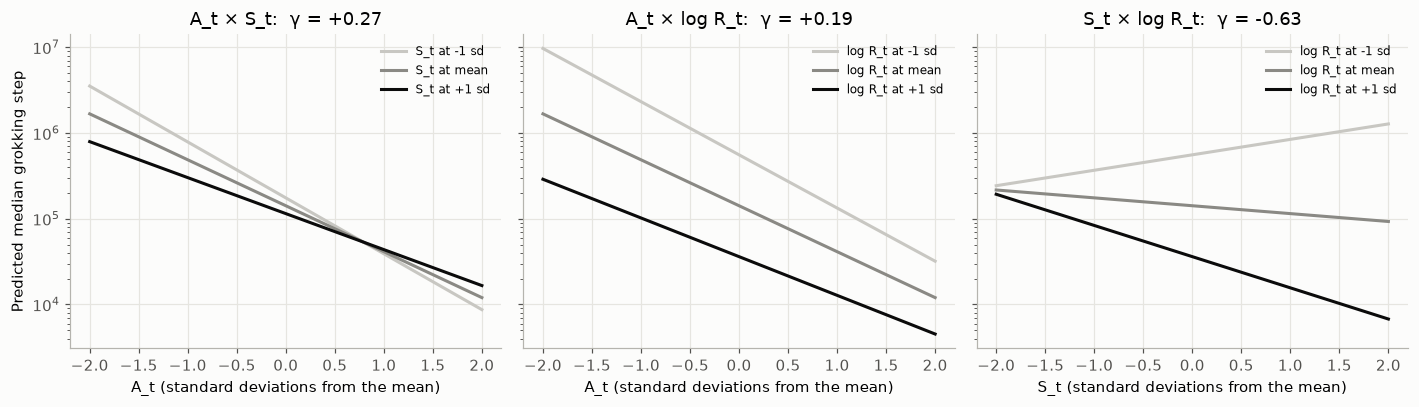

In [7]:
shown = {'A_t': 'A_t', 'S_t': 'S_t', 'R_t': 'log R_t'}
gamma = fits['log R_t'].params_.loc['mu_']
grid = np.linspace(-2, 2, 50)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (a, b) in zip(axes, pairs):
    for level, shade, label in zip([-1, 0, 1], [PALE, GREY, INK], ['-1 sd', 'mean', '+1 sd']):
        probe = pd.DataFrame(0.0, index=range(len(grid)), columns=kernel)
        probe[a], probe[b] = grid, level
        for p, q in pairs:
            probe[f'{p} × {q}'] = probe[p] * probe[q]
        ax.plot(grid, fits['log R_t'].predict_median(probe[list(design(data, 'log R_t'))]).to_numpy().ravel(), color=shade, label=f'{shown[b]} at {label}')
    ax.set_title(f'{shown[a]} × {shown[b]}:  γ = {gamma[f"{a} × {b}"]:+.2f}')
    ax.set_yscale('log')
    ax.set_xlabel(f'{shown[a]} (standard deviations from the mean)')
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('Predicted median grokking step')
plt.tight_layout()
plt.show()

**What this shows**
- The three interaction terms improve the fit in all three versions (LR 37.8, 76.9 and 133.3). The p-values are too small because seeds are near copies, but these statistics are far beyond any threshold. Adding squares does not remove the need for interactions. The statistics combine, and their effects do not add up one by one.
- Three findings hold in every version. More alignment (`A_t`) and more rotation (`R_t`) go with earlier grokking, and $\gamma_{AS}$ is positive. In the main version the range of $\gamma_{AS}$ just touches 0 (−0.02 to 0.54).
- Three findings depend on the version. `S_t` on its own is clearly negative only with raw `R_t`. $\gamma_{AR}$ is clearly negative only with raw `R_t`, so it most likely stood in for the curve of `R_t` that the log takes care of. $\gamma_{SR}$ is clearly negative only once `R_t` is on a log scale (−0.63, range −1.45 to −0.05).
- The curves show the strongest interaction, `S_t` × log `R_t`. When the kernel has rotated (log `R_t` one standard deviation above its mean), more growth means sooner grokking, and the predicted median falls about 30 times across the range of `S_t`. When it has hardly rotated, more growth means later grokking. Growth helps only together with rotation.
- In `A_t` × `S_t`, alignment speeds grokking a little more when the kernel has grown less. In `A_t` × log `R_t` the curves are close to parallel.
- So we can trust the effects of `A_t` and `R_t` and the need for interactions. A claim about one particular pair should be checked against the scale used for `R_t`.

## Part 3. Can the statistics rank runs from an `alpha` the model has never seen?

**Question.** Fit on two values of `alpha` and predict the third. Does the model still put runs in the right order?

We climb a ladder of models. All of them use $z_A$, $z_S$ and $z_R$ with log `R_t`.
1. Each statistic on its own, in a linear AFT.
2. The linear AFT on all three, without and then with the interaction terms.
3. **Kernel ridge regression.** It fits a smooth curved surface. It predicts $\log T$, so it only learns from runs that grokked.
4. **XGBoost.** A sum of small decision trees, each one fitted to the errors of the trees before it. Its `survival:aft` objective uses the same likelihood as the AFT, so it keeps the censored runs.

As a reference we also fit **XGBoost on the settings only**: width and weight decay, without the kernel. `alpha` is the held-out factor, so it cannot be used. If a kernel model does no better than this, the kernel adds nothing that the settings do not already give.

In [8]:
pred = pd.DataFrame(index=data.index, columns=['A_t only', 'S_t only', 'R_t only', 'linear AFT', 'linear AFT + interactions', 'kernel ridge'], dtype=float)
for a in alphas:
    train, test = (data['alpha'] != a).to_numpy(), (data['alpha'] == a).to_numpy()
    for name, interactions in [('linear AFT', False), ('linear AFT + interactions', True)]:
        X = design(data, 'log R_t', interactions, ref=data[train])
        pred.loc[test, name] = fit_aft(data[train], X[train], penalizer=0.01).predict_median(X[test]).to_numpy().ravel()
    X = design(data, 'log R_t', False, ref=data[train])
    for stat in kernel:
        aft = fit_aft(data[train], X.loc[train, [stat]], penalizer=0.01)
        pred.loc[test, f'{stat} only'] = aft.predict_median(X.loc[test, [stat]]).to_numpy().ravel()

Kernel ridge next, and the tools XGBoost needs: the validation split and the search over its settings.

In [9]:
XGB_BASE = {'objective': 'survival:aft', 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.0,
            'subsample': 0.8, 'eval_metric': 'aft-nloglik'}
XGB_GRID = [{'max_depth': d, 'eta': e, 'min_child_weight': w} for d, e, w in itertools.product([1, 2, 3, 4], [0.03, 0.1], [1, 5, 10])]
log_T = np.log(data['T'])
upper = np.where(data['grokked'] == 1, data['T'], np.inf)     # a censored run's T can be anything above 200,000


def validation_split(train, seed):
    # Hold out 20% of the training cells as a validation set. Returns the fitting rows and the validation rows.
    cells = data.loc[train, 'cell'].unique()
    held = np.random.default_rng(seed).choice(cells, round(0.2 * len(cells)), replace=False)
    val = train & data['cell'].isin(held).to_numpy()
    return train & ~val, val


def aft_matrix(X, rows):
    m = xgb.DMatrix(X[rows])
    m.set_float_info('label_lower_bound', data['T'].to_numpy()[rows])
    m.set_float_info('label_upper_bound', upper[rows])
    return m


def tuned_xgb(X, train, seed):
    # Try every setting on the validation set, keep the best, and refit it on all training runs.
    fit, val = validation_split(train, seed)
    best = (-1, None, None)
    for setting in XGB_GRID:
        params = {**XGB_BASE, **setting, 'seed': seed}
        booster = xgb.train(params, aft_matrix(X, fit), 1000, evals=[(aft_matrix(X, val), 'validation')],
                            early_stopping_rounds=50, verbose_eval=False)
        rounds = booster.best_iteration + 1
        c = concordance_index(data['T'].to_numpy()[val], booster.predict(aft_matrix(X, val), iteration_range=(0, rounds)),
                              data['grokked'].to_numpy()[val])
        if c > best[0]:
            best = (c, params, rounds)
    return xgb.train(best[1], aft_matrix(X, train), best[2]), best


for a in alphas:
    train, test = (data['alpha'] != a).to_numpy(), (data['alpha'] == a).to_numpy()
    X = design(data, 'log R_t', False, ref=data[train])
    g = train & (data['grokked'] == 1).to_numpy()
    krr = GridSearchCV(KernelRidge(kernel='rbf'), {'alpha': [0.01, 0.1, 1], 'gamma': [0.1, 0.5, 2]}, cv=GroupKFold(5))
    krr.fit(X[g], log_T[g], groups=data.loc[g, 'cell'])
    pred.loc[test, 'kernel ridge'] = np.exp(krr.predict(X[test]))

XGBoost runs with 5 seeds, on the kernel and on the settings only. The table shows the settings XGBoost chose with seed 0.

In [10]:
settings_X = np.column_stack([np.log(data['width']), np.log10(data['eta_kappa'].where(data['eta_kappa'] > 0, 1e-6))])     # trees only use the order, so where 0 sits does not matter
xgb_scores, chosen = [], {}
for seed in range(5):
    for name in ['XGBoost', 'XGBoost, settings only']:
        p = np.zeros(len(data))
        for a in alphas:
            train, test = (data['alpha'] != a).to_numpy(), (data['alpha'] == a).to_numpy()
            X = design(data, 'log R_t', False, ref=data[train]).to_numpy() if name == 'XGBoost' else settings_X
            booster, best = tuned_xgb(X, train, seed)
            p[test] = booster.predict(xgb.DMatrix(X[test]))
            if seed == 0 and name == 'XGBoost':
                chosen[f'alpha {a:g} held out'] = {'depth': best[1]['max_depth'], 'learning rate': best[1]['eta'], 'min child weight': best[1]['min_child_weight'],
                                                   'rounds': best[2], 'validation concordance': round(best[0], 3)}
        xgb_scores.append({'model': name, 'seed': seed, **{f'alpha {a:g}': concordance_index(data.loc[data['alpha'] == a, 'T'], p[data['alpha'] == a], data.loc[data['alpha'] == a, 'grokked']) for a in alphas}})
xgb_scores = pd.DataFrame(xgb_scores)
xgb_scores['mean'] = xgb_scores[[f'alpha {a:g}' for a in alphas]].mean(axis=1)
pd.DataFrame(chosen).T

,depth,learning rate,min child weight,rounds,validation concordance
alpha 0.5 held out,1.0,0.03,10.0,295.0,0.806
alpha 1 held out,3.0,0.10,5.0,126.0,0.917
alpha 2 held out,4.0,0.03,10.0,470.0,0.805


### The scores

The bar is the mean concordance over the three held-out values of `alpha`. The dots are the three folds. For XGBoost the bar is the mean of 5 seeds and the line is the range over seeds.

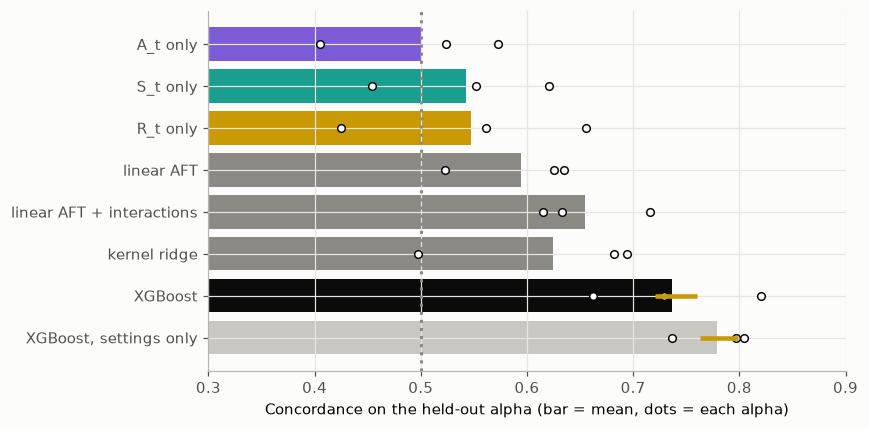

XGBoost range over 5 seeds: {'XGBoost': {'min': 0.72, 'max': 0.76}, 'XGBoost, settings only': {'min': 0.763, 'max': 0.799}}


,alpha 0.5,alpha 1,alpha 2,mean
A_t only,0.573,0.524,0.405,0.501
S_t only,0.621,0.552,0.454,0.542
R_t only,0.655,0.561,0.425,0.547
linear AFT,0.635,0.625,0.523,0.594
linear AFT + interactions,0.716,0.633,0.615,0.655
kernel ridge,0.694,0.682,0.497,0.625
XGBoost,0.729,0.662,0.820,0.737
"XGBoost, settings only",0.737,0.804,0.796,0.779


In [11]:
fold_cols = [f'alpha {a:g}' for a in alphas]
scores = pd.DataFrame({name: {f'alpha {a:g}': concordance_index(data.loc[data['alpha'] == a, 'T'], pred.loc[data['alpha'] == a, name], data.loc[data['alpha'] == a, 'grokked'])
                              for a in alphas} for name in pred}).T
for name, g in xgb_scores.groupby('model', sort=False):
    scores.loc[name] = g[fold_cols].mean()
scores['mean'] = scores[fold_cols].mean(axis=1)
seed_range = xgb_scores.groupby('model')['mean'].agg(['min', 'max'])

fig, ax = plt.subplots(figsize=(8, 4))
colours = [KERNEL_COLOURS['A_t'], KERNEL_COLOURS['S_t'], KERNEL_COLOURS['R_t'], GREY, GREY, GREY, INK, PALE]
ax.barh(scores.index, scores['mean'], color=colours)
for i, (name, row) in enumerate(scores.iterrows()):
    ax.scatter(row[fold_cols], [i] * 3, color='white', edgecolors=INK, s=25, zorder=3)
    if name in seed_range.index:
        ax.hlines(i, seed_range.loc[name, 'min'], seed_range.loc[name, 'max'], color=KERNEL_COLOURS['R_t'], linewidth=3, zorder=4)
ax.axvline(0.5, color=GREY, linestyle=':')
ax.set_xlim(0.3, 0.9)
ax.invert_yaxis()
ax.set_xlabel('Concordance on the held-out alpha (bar = mean, dots = each alpha)')
plt.tight_layout()
plt.show()
print('XGBoost range over 5 seeds:', seed_range.round(3).to_dict('index'))
scores.round(3)

**What this shows**
- Each statistic alone ranks runs about as well as a coin toss on average (0.50 to 0.55). Each one helps on one `alpha` and fails on another.
- The linear AFT scores 0.594, and the interaction terms lift it to 0.655. With raw `R_t` instead of log `R_t`, the same two models score 0.550 and 0.631, so the log scale helps both.
- Kernel ridge scores 0.625 and fails on `alpha` 2 (0.497). It learns from grokked runs only, and `alpha` 2 lies at the edge of their data.
- XGBoost is the best kernel model, with a mean of 0.737 over 5 seeds (0.720 to 0.760). The relation is non-linear, and a linear model with interactions finds only part of it.
- XGBoost on the settings alone scores 0.779 (0.763 to 0.799 over seeds), above every kernel model. On a new `alpha`, the kernel statistics tell us nothing about grokking time that width and weight decay do not already tell us. Notebook 4 (Part 2) shows why: the statistics are almost fully set by the settings.
- XGBoost chose different settings in each fold: depth 1 when `alpha` 0.5 is held out, and depth 3 or 4 otherwise. Its validation concordance (0.81 to 0.92) is far above the test score. The validation cells come from the training values of `alpha`, so validation measures fit inside known `alpha` values, while the test measures a new one.

## Part 4. What shape did XGBoost find?

**Question.** What does the fitted relation look like for each statistic?

We fit XGBoost once on all runs, choosing its settings on a validation set of 20% of the cells. Then we slide one statistic from low to high, hold the other two at their median, and plot the predicted grokking step. A flat line means the statistic has no effect at the median of the others. The statistics are correlated, so some points on a slice lie where there are no runs. Read the parts of each curve where most runs sit.

chosen: {'max_depth': 3, 'eta': 0.03, 'min_child_weight': 1} rounds: 239


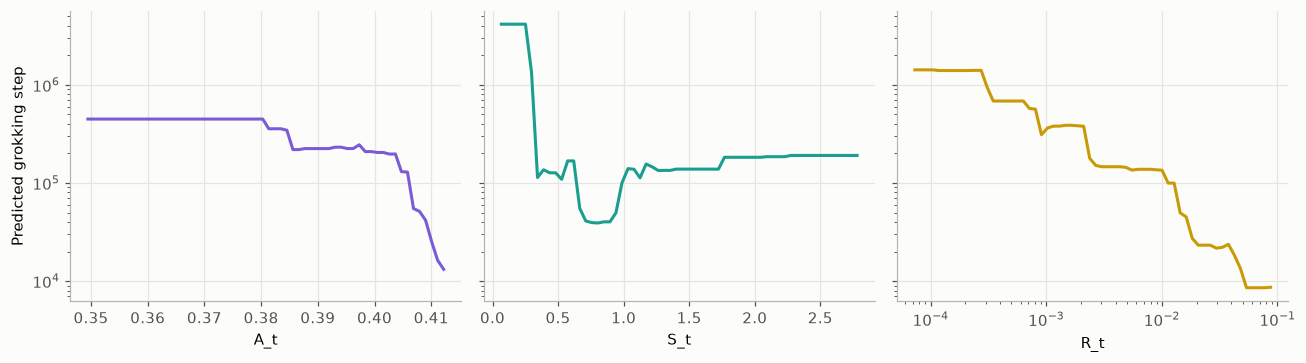

In [12]:
X_all = design(data, 'log R_t', False)
booster, best = tuned_xgb(X_all.to_numpy(), np.ones(len(data), dtype=bool), seed=0)
print('chosen:', {k: best[1][k] for k in ['max_depth', 'eta', 'min_child_weight']}, 'rounds:', best[2])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, stat, col in zip(axes, kernel, covs):
    grid = np.linspace(X_all[stat].quantile(0.02), X_all[stat].quantile(0.98), 60)
    probe = pd.DataFrame({c: np.full(60, X_all[c].median()) for c in kernel})
    probe[stat] = grid
    x = grid * data[col].std() + data[col].mean()
    ax.plot(np.exp(x) if stat == 'R_t' else x, booster.predict(xgb.DMatrix(probe.to_numpy())), color=KERNEL_COLOURS[stat])
    ax.set_yscale('log')
    ax.set_xlabel(stat)
axes[2].set_xscale('log')
axes[0].set_ylabel('Predicted grokking step')
plt.tight_layout()
plt.show()

### Two statistics at once

This map holds `A_t` at its median and varies `S_t` and `R_t` together. Darker means a later predicted grokking step. The dots are the runs. Away from the dots the map is a guess.

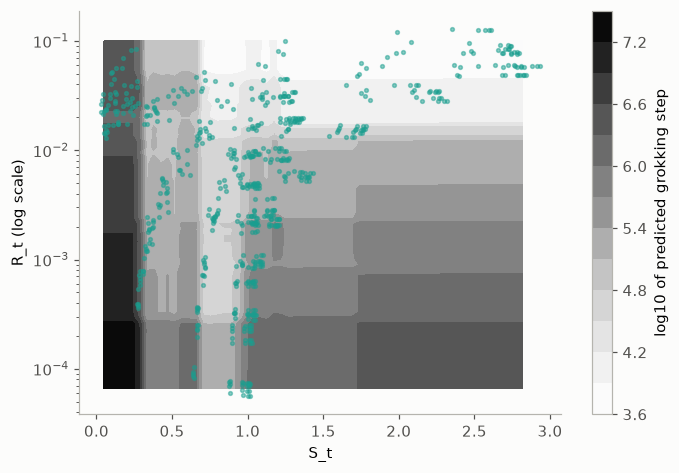

In [13]:
S, logR = np.meshgrid(np.linspace(data['S_t'].quantile(0.01), data['S_t'].quantile(0.99), 60),
                      np.linspace(data['log R_t'].quantile(0.01), data['log R_t'].quantile(0.99), 60))
probe = pd.DataFrame({'A_t': data['A_t'].median(), 'S_t': S.ravel(), 'log R_t': logR.ravel()})
surface = booster.predict(xgb.DMatrix(design(probe, 'log R_t', False).to_numpy())).reshape(S.shape)

fig, ax = plt.subplots(figsize=(6.4, 4.4))
im = ax.contourf(S, np.exp(logR), np.log10(surface), levels=12, cmap='Greys')
ax.scatter(data['S_t'], data['R_t'], s=6, color=KERNEL_COLOURS['S_t'], alpha=0.5)
fig.colorbar(im, label='log10 of predicted grokking step')
ax.set_yscale('log')
ax.set_xlabel('S_t')
ax.set_ylabel('R_t (log scale)')
ax.grid(False)
plt.tight_layout()
plt.show()

**What this shows**
- `S_t` has a best middle range. Kernels that shrank (`S_t` below about 0.3) are predicted never to grok. Runs with `S_t` between about 0.7 and 1.0 are predicted to grok earliest, and above 1.0 the prediction rises again.
- `R_t` lowers the predicted step more than 100 times between $10^{-4}$ and 0.05, at a steady rate on the log scale, and then levels off. This is the log-shaped effect that Part 1 suggested.
- `A_t` does little below 0.38 and lowers the predicted step sharply above 0.40.
- On the map, the earliest predictions need `S_t` above about 0.65. Above `S_t` of about 1, they also need `R_t` above about 0.02. A kernel that grows a lot must also rotate, which is the `S_t` × `R_t` interaction of Part 2.
- The steps in the curves come from tree splits, so small wiggles carry no meaning. Predicted steps above 200,000 lie beyond the step budget, and only their order matters.

## Part 5. Does the history of the kernel add information?

**Question.** Each run has the statistics at 25 saved steps up to $t^*$, a short time series. Is that series autocorrelated? And does it predict better than the last point alone?

First, what the series look like. Each line is one run, for 25 runs that grokked and 25 that never did.

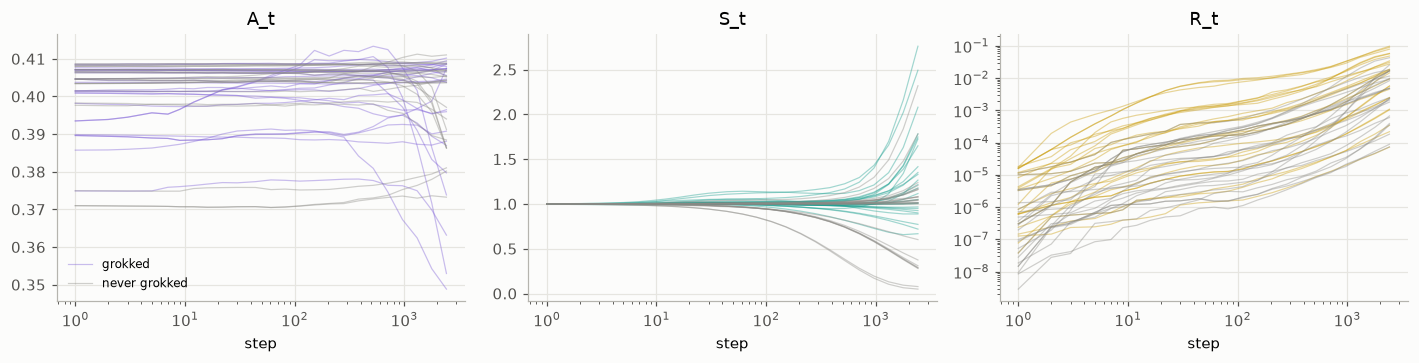

In [14]:
before = kern[kern['step'] <= T_STAR].pivot(index='run_id', columns='step', values=kernel)
history = np.stack([before[k].loc[data['run_id']].to_numpy() for k in kernel], axis=-1)     # runs × 25 saved steps × 3 statistics
steps = before['A_t'].columns.to_numpy()

rng = np.random.default_rng(1)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for i, (ax, stat) in enumerate(zip(axes, kernel)):
    for outcome, colour, label in [(1, KERNEL_COLOURS[stat], 'grokked'), (0, GREY, 'never grokked')]:
        for k, r in enumerate(rng.choice(np.flatnonzero(data['grokked'] == outcome), 25, replace=False)):
            ax.plot(steps[1:], history[r, 1:, i], color=colour, alpha=0.4, linewidth=0.8, label=label if k == 0 else None)
    ax.set_xscale('log')
    ax.set_xlabel('step')
    ax.set_title(stat)
axes[2].set_yscale('log')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Now the autocorrelation: the correlation between a series and itself one saved step earlier. The saved steps are spaced on a log scale, so near $t^*$ the previous step is about 1.36 times earlier. We measure it for the level and for the change between steps, and give the median over runs. The Ljung-Box test asks if the changes have any autocorrelation up to lag 3. The last column is the share of runs where it says yes at the 5% level.

In [15]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

rows = {}
for i, stat in enumerate(kernel):
    level, change = history[:, :, i], np.diff(history[:, :, i], axis=1)
    rows[stat] = {'lag-1 autocorrelation of the level': np.median([acf(r, nlags=1)[1] for r in level]),
                  'lag-1 autocorrelation of the change': np.median([acf(r, nlags=1)[1] for r in change]),
                  'share of runs with Ljung-Box p < 0.05': np.mean([acorr_ljungbox(r, lags=[3])['lb_pvalue'].iloc[0] < 0.05 for r in change])}
pd.DataFrame(rows).T.round(3)

,lag-1 autocorrelation of the level,lag-1 autocorrelation of the change,share of runs with Ljung-Box p < 0.05
A_t,0.710,0.331,0.444
S_t,0.684,0.647,0.921
R_t,0.618,0.600,0.857


**What this shows**
- `R_t` grows steadily on these log axes, close to a power of the step, and runs that grok sit higher. `S_t` stays at 1 until about step 100, then grows or shrinks. `A_t` is flat for most runs, but in some runs that grok it drops in the last few hundred steps before $t^*$. This explains the early-grokking group with low `A_t` in Part 1.
- All three series are strongly autocorrelated. For `S_t` and `R_t` even the changes are (median lag-1 autocorrelation 0.65 and 0.60), and Ljung-Box finds autocorrelation in 92% and 86% of runs. For `A_t` it is weaker (0.33, found in 44% of runs).
- This is expected. Full-batch gradient descent has no sampling noise, so the kernel moves along a smooth trajectory. Autocorrelation shows structure over time, but it does not show that the structure predicts `T`. The models below test that.

### Models of the history

We use the hold-one-`alpha`-out test of Part 3 with 3 seeds and compare three models.
- **XGBoost, cross-sectional.** The XGBoost of Part 3, which sees the statistics at $t^*$ only. Its scores are seeds 0 to 2 from Part 3.
- **XGBoost, longitudinal.** XGBoost on all 75 values of the history (25 steps × 3 statistics) as one row. Trees ignore the time order.
- **GRU, longitudinal.** A gated recurrent unit network with 16 hidden units. It reads the history one step at a time, in time order, and predicts $\log T$ from its final state. It is trained with the AFT likelihood, so censored runs still count as "above 200,000". Its learning rate (0.01) and weight decay ($10^{-4}$) are fixed. Early stopping chooses the number of epochs: we fit on 80% of the training cells, check the loss on the other 20% every 10 epochs up to 800, and keep the best weights.

PyTorch runs on one thread here, because PyTorch and XGBoost each bring their own copy of OpenMP and can otherwise hang the kernel.

GRU epochs chosen by early stopping: [60, 90, 100, 120, 130, 150, 230, 280, 290]


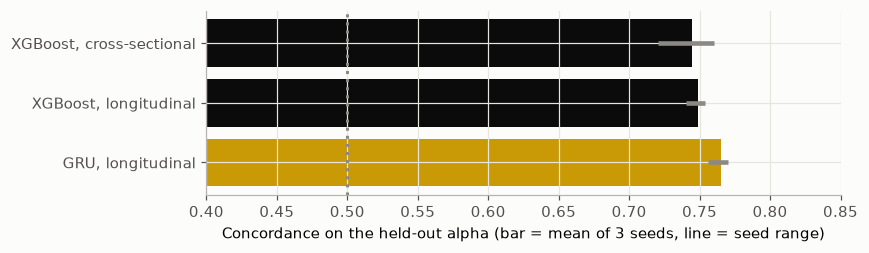

,alpha 0.5,alpha 1,alpha 2,mean,lowest seed,highest seed
model,,,,,,
"XGBoost, cross-sectional",0.729,0.676,0.828,0.744,0.720,0.760
"XGBoost, longitudinal",0.739,0.723,0.785,0.749,0.740,0.754
"GRU, longitudinal",0.777,0.727,0.791,0.765,0.756,0.770


In [16]:
import torch
torch.set_num_threads(1)


def aft_loss(mu, log_sigma, y, grokked):
    # Log-normal AFT loss: the density for runs that grokked, the chance of a later step for runs that did not.
    z = (y - mu) / log_sigma.exp()
    normal = torch.distributions.Normal(0.0, 1.0)
    return -(grokked * (normal.log_prob(z) - log_sigma) + (1 - grokked) * torch.log(normal.cdf(-z) + 1e-12)).mean()


class GRU(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = torch.nn.GRU(3, 16, batch_first=True)
        self.head = torch.nn.Linear(16, 1)
        self.log_sigma = torch.nn.Parameter(torch.zeros(()))

    def forward(self, x):
        return self.head(self.gru(x)[1][-1]).squeeze(-1)


def train_gru(z, train, seed):
    # Fit on 80% of the training cells and keep the weights with the lowest loss on the other 20%.
    fit, val = validation_split(train, seed)
    y = (log_T - log_T[train].mean()) / log_T[train].std()
    Z, Y, E = (torch.tensor(np.asarray(v), dtype=torch.float32) for v in (z, y, data['grokked']))
    torch.manual_seed(seed)
    net = GRU()
    opt = torch.optim.Adam(net.parameters(), lr=1e-2, weight_decay=1e-4)
    best = (np.inf, None, 0)
    for epoch in range(1, 801):
        opt.zero_grad()
        aft_loss(net(Z[fit]), net.log_sigma, Y[fit], E[fit]).backward()
        opt.step()
        if epoch % 10 == 0:
            with torch.no_grad():
                loss = aft_loss(net(Z[val]), net.log_sigma, Y[val], E[val]).item()
            if loss < best[0]:
                best = (loss, copy.deepcopy(net.state_dict()), epoch)
    net.load_state_dict(best[1])
    return net, best[2]


hist_scores, epochs = [], {}
for seed in range(3):
    preds = {name: np.zeros(len(data)) for name in ['XGBoost, longitudinal', 'GRU, longitudinal']}
    for a in alphas:
        train, test = (data['alpha'] != a).to_numpy(), (data['alpha'] == a).to_numpy()
        z = (history - history[train].mean(axis=(0, 1))) / history[train].std(axis=(0, 1))
        booster, _ = tuned_xgb(z.reshape(len(z), -1), train, seed)
        preds['XGBoost, longitudinal'][test] = booster.predict(xgb.DMatrix(z.reshape(len(z), -1)[test]))
        net, epochs[seed, a] = train_gru(z, train, seed)
        with torch.no_grad():
            preds['GRU, longitudinal'][test] = net(torch.tensor(z[test], dtype=torch.float32)).numpy()
    for name, p in preds.items():
        hist_scores.append({'model': name, 'seed': seed, **{f'alpha {a:g}': concordance_index(data.loc[data['alpha'] == a, 'T'], p[data['alpha'] == a], data.loc[data['alpha'] == a, 'grokked']) for a in alphas}})

cross = xgb_scores[(xgb_scores['model'] == 'XGBoost') & (xgb_scores['seed'] < 3)].assign(model='XGBoost, cross-sectional')
compare = pd.concat([cross, pd.DataFrame(hist_scores)], ignore_index=True)
compare['mean'] = compare[fold_cols].mean(axis=1)
summary = compare.groupby('model', sort=False)[fold_cols + ['mean']].mean()
summary['lowest seed'] = compare.groupby('model', sort=False)['mean'].min()
summary['highest seed'] = compare.groupby('model', sort=False)['mean'].max()
print('GRU epochs chosen by early stopping:', sorted(epochs.values()))

fig, ax = plt.subplots(figsize=(8, 2.4))
ax.barh(summary.index, summary['mean'], color=[INK, INK, KERNEL_COLOURS['R_t']])
ax.hlines(range(len(summary)), summary['lowest seed'], summary['highest seed'], color=GREY, linewidth=3)
ax.axvline(0.5, color=GREY, linestyle=':')
ax.set_xlim(0.4, 0.85)
ax.invert_yaxis()
ax.set_xlabel('Concordance on the held-out alpha (bar = mean of 3 seeds, line = seed range)')
plt.tight_layout()
plt.show()
summary.round(3)

**What this shows**
- The GRU on the history scores 0.765 (seeds 0.756 to 0.770). XGBoost at $t^*$ scores 0.744 over the same 3 seeds (0.720 to 0.760). The gain of about 0.02 is half the seed spread of XGBoost.
- The GRU gains on `alpha` 0.5 (0.777 against 0.729) and `alpha` 1 (0.727 against 0.676), and loses on `alpha` 2 (0.791 against 0.828).
- XGBoost on the history scores 0.749, close to its score at $t^*$. Trees treat the 75 values as unrelated columns, while the GRU reads them in time order.
- Early stopping chose between 60 and 290 epochs. Each fold needs its own number, so a fixed number of epochs would overfit some folds.
- Even the GRU stays below XGBoost on the settings alone (0.779, Part 3). The time structure helps a little, and a recurrent model can use it, but it does not add information beyond the settings.

## Summary

| Question | Answer |
| --- | --- |
| Are the statistics linked to grokking time? | Yes. More alignment and more rotation at $t^*$ go with earlier grokking, on every scale we tried. |
| On what scale does `R_t` act? | A log scale. It improves the fit and raises the held-out score of the linear AFT from 0.550 to 0.594. |
| Do the statistics interact? | Yes. The interaction terms improve the fit on every scale. The clearest pair is `S_t` × log `R_t`: growth helps only with rotation. `A_t` × `S_t` keeps its sign on every scale. `A_t` × `R_t` appears only with raw `R_t`. |
| What shape is the relation? | Non-linear. `S_t` has a best middle range near 0.7 to 1.0, `R_t` acts on a log scale and levels off near 0.05, and `A_t` matters mostly above 0.40. |
| Can the statistics rank runs from a new `alpha`? | Partly. XGBoost scores 0.737 and the linear AFT with interactions 0.655, against 0.5 for a coin toss. |
| Does the history of the statistics help? | A little. The series are strongly autocorrelated, and a GRU on the history scores 0.765. |
| Do the statistics beat the settings? | No. XGBoost on width and weight decay scores 0.779 (0.763 to 0.799). |

## How to model these data
1. Use log `R_t`, not `R_t`.
2. Let `S_t` bend, with a square term or a spline. A straight line cannot show a best middle range.
3. Include interaction terms, at least `S_t` × log `R_t` and `A_t` × `S_t`. Check any claim about a single pair against the scale used for `R_t`.
4. When runs that never grok are included, use a model that handles censoring, such as the AFT or XGBoost with `survival:aft`.
5. Compare every kernel model with a model of the settings alone. The statistics mostly carry the settings, so only a gain over the settings shows information of their own.

## Conclusion

Read before any run groks, the kernel statistics rank runs from a held-out `alpha` well above chance. Alignment and rotation push toward earlier grokking, `R_t` acts on a log scale, `S_t` has a best middle range, and growth helps only with rotation. XGBoost captures this best at about 0.74, and a GRU on the history gains about 0.02 more.

A flexible model of width and weight decay alone does better (0.779). The kernel statistics are close to a readout of the settings, as notebook 4 (Part 2) shows. Two tests would show whether they carry more: ranking the seeds within each cell, and holding out one weight decay level at a time.